# Analysis of v5 simulations

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plot_tools
from scipy.interpolate import griddata
import george
from scipy.optimize import minimize

%matplotlib widget

In [66]:
# This just defines the colours and markers to use for the metrics in the plots
metric_colors = {'fom':'C0',
            'lss':'C1',
            'wl':'C2',
            'sn':'C3',
            'kn2':'C3',
            'sl':'C4',
            'snz':'C5',
            'kn':'C6',
            'pz':'C9'
        }

metric_markers = {'fom':'o',
        'lss':'^',
        'wl':'s',
        'sn':'*',
        'kn2':'*',
        'snz':'P',
        'sl':'D',
        'kn':'X',
        'pz':'+'
    }

## Select metrics to plot
We start by selecting which metrics we want to plot and provide shorter display names. In order to convert the metrics correctly for comparison, we need to know if any transforms need to be applied (see Lochner et al. 2022 for futher details). Possibilities include: <br>

invert = $1/x$ <br>
convert_to_flux = $10^{(-x/2.5)}$ <br>
convert_to_precision = $1/x^2$ <br>
one_minus = $1-2x$

In [67]:
# This spreadsheet contains the correct conversions for each metric and standard names for them
metric_names = pd.read_csv('OS_metric_translations.csv', index_col=0)
metric_names.columns

Index(['desc_metric_name', 'desc_metric_display_name', 'maf_metric_v1_5_name',
       'maf_metric_v2_0_name', 'maf_metric_v3_0_name', 'transform_invert',
       'transform_mag_to_flux', 'transform_to_precision',
       'transform_one_minus', 'validated', 'comment'],
      dtype='object')

## Metric files
**Update for v3.6 simulations**: The summary file can be found at https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs3.6/maf/summary.h5 and I've extracted relevant metrics and placed it in `desc_metrics_summary_v3.4.csv`.

**Update for v4.3 simulations**: The summary file can be found at https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/maf/summary.h5 and I've extracted relevant metrics and placed it in `desc_metrics_summary_v4.3.csv`.

**Update for v5 simulations**: The summary file can be found at https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.x/maf/summary.h5 and I've extracted relevant metrics and placed it in `desc_metrics_summary_v5.x.csv`. where x is either 0 or 1.


In [68]:
# Where the local copy of the summary file is
analysis_dir = 'FBS_analysis/' 

In [69]:
maf_output_summary_file = analysis_dir + 'desc_metrics_summary_v5.0.csv'
maf_output_full = pd.read_csv(maf_output_summary_file, index_col=0)

In [70]:
maf_columns = []
for idx in metric_names.index:
    maf_columns.append(metric_names.loc[idx, 'maf_metric_v3_0_name'])

In [71]:
maf_output = maf_output_full[maf_columns]

In [72]:
baseline = 'baseline_v5.0.1_10yrs'

## Compute the metrics relative to baseline
We always compare metrics by subtracting their value at baseline, and then dividing by their value at baseline. So all metrics can be considered as percentage improvement or degradation.

In [73]:
def compute_relative_improvement(metric_series, 
                                 baseline, 
                                 invert=False,
                                 convert_to_flux=False,
                                 convert_to_precision=False,
                                 one_minus=False):
    """
    Calculates the improvement of the metric over the given baseline, including applying the appropriate 
    transforms. Transforms are applied in the same order as used in Lochner et al. so for instance, a value
    will first be converted to flux and then to precision.
    """
    if convert_to_flux:
        metric_series = 10**(-metric_series/2.5)

    if one_minus:
        metric_series = 1 - 2*metric_series

    if invert:
        metric_series = 1/metric_series

    if convert_to_precision:
        metric_series = 1/metric_series**2
        
    baseline_value = metric_series.loc[baseline]
    
    return (metric_series - baseline_value)/baseline_value   

In [74]:
maf_output_rel = maf_output.copy()
for idx in metric_names.index:
    metric = metric_names.loc[idx, 'maf_metric_v3_0_name']
    rel_series = compute_relative_improvement(maf_output[metric], 
                                 baseline,
                                 metric_names.loc[idx, 'transform_invert'], 
                                 metric_names.loc[idx, 'transform_mag_to_flux'],
                                 metric_names.loc[idx, 'transform_to_precision'],
                                 metric_names.loc[idx, 'transform_one_minus'])
    maf_output_rel[metric] = rel_series

At this point, we have 3 important dataframes: <br>
- `metric_names`: contains a key for each metric, its nice display name and the long name in the MAF file
- `maf_output`: the original MAF summary file for all the metrics we care about (i.e. their raw values for each sim)
- `maf_output_rel`: the relative improvement for each metric over baseline, after each metric has been transformed appropriately

## Functions

### Individual sims plot function
Function to plot a set of simulations for some metrics

In [75]:
def plot_individual_sims(metrics_rel, metric_names, list_of_sims, tick_labels=[], probes=[], labels_dict={}, error_dict={}, 
                         ylabel='', xlabel='',
                         save_plot=False, savefig_path='', expand_ylim_by=[1.1, 1.1],
                         legend_outside=False, figsize=(8,4), plot_vertical=False):
    """
    Plots the relative metrics for a subset of simulations.
    
    Parameters
    ----------
    metrics_rel : pd.DataFrame
        The metrics appropriately transformed and expressed as relative improvement over baseline for all 
        metrics (columns) for each simulation (row).
    metric_names: pd.DataFrame
        A translation between what the metric was called in the Lochner et al. paper and its name in the MAF summary file.
    list_of_sims: list of strings
        Which simulations to plot on the x axis. Note this should be a short list to maintain readability.
    tick_labels: list of strings
        Allows overwriting of the tick labels if you want to use shorter forms of the simulation names
    probes: list of strings
        Which probes to plot, uses the short hand in "metric_names" to translate them. A good base set is 
         ['fom', 'wl', 'sn', 'kn', 'sl']
    ylabel: string, optional
        Label for y axis
    xlabel: string, optional
        Label for x axis
    save_plot: bool, optional
        Whether or not to save the figure to file
    savefig_path: string, optional
        Filename and path for the figure if saving it
    expand_ylim_by: list, optional
        Two values to allow expanding of the y axis to accommodate large legends. E.g. [1.1, 1.4] will expand the top y
        limit of the plot by 40% of the maximum value.
    legend_outside: bool, optional
        If true, will place the legend outside the plot area. The figure size may need to be adjusted.
    figsize: tuple, optional
        Matplotlib figsize
    plot_vertical: boolean, optional
        If true, will flip the axes so the simulations are on the y-axis.
        
    """
                         
    plt.figure(figsize=figsize)
    x = np.arange(len(list_of_sims))
    xlim = [-0.1, len(x)-1+0.1]
    capsize = 6
    if plot_vertical:
        plt.plot([0]*len(xlim), xlim, 'k--', alpha=0.5)
    else:
        plt.plot(xlim, [0]*len(xlim), 'k--', alpha=0.5)
    if len(tick_labels) == 0:
        tick_labels = list_of_sims

    for p in probes:
        metric = metric_names.loc[p, 'maf_metric_v3_0_name']
        y = metrics_rel.loc[list_of_sims, metric].astype('float')
        if len(labels_dict) == 0:
            label = metric_names.loc[p, 'desc_metric_display_name']
        else:
            label = labels_dict[p]

        if plot_vertical:
            if len(error_dict) == 0:
                plt.plot(y, x, label=label, 
                 color=metric_colors[p], marker=metric_markers[p])
            else:
                # plt.errorbar(y, x, xerr=error_dict[p], label=label, 
                #  color=metric_colors[p], marker=metric_markers[p], capsize=capsize)
                upper = y + error_dict[p]
                lower = y - error_dict[p]
                plt.fill_betweenx(x, lower, upper, color=metric_colors[p], alpha=0.2)
                plt.plot(y, x, label=label, 
                 color=metric_colors[p], marker=metric_markers[p])
        else:
            if len(error_dict) == 0:
                plt.plot(x, y, label=label, 
                 color=metric_colors[p], marker=metric_markers[p])
            else:
                # plt.errorbar(x, y, yerr=error_dict[p], label=label, 
                #  color=metric_colors[p], marker=metric_markers[p], capsize=capsize)
                upper = y + error_dict[p]
                lower = y - error_dict[p]
                plt.fill_between(x, lower, upper, color=metric_colors[p], alpha=0.2)
                plt.plot(x, y, label=label, 
                 color=metric_colors[p], marker=metric_markers[p])
        
    
    if legend_outside:
        plt.legend(bbox_to_anchor=(1.1, 1.00))
    else:
        plt.legend()
    
    ax = plt.gca()
    if plot_vertical:
        plt.yticks(x, tick_labels)
        plt.ylabel(xlabel)
        plt.xlabel(ylabel)
        ylim = ax.get_xlim()
        new_ylim = [ylim[0]*expand_ylim_by[0], ylim[1]*expand_ylim_by[1]]
        plt.xlim(new_ylim)
        plt.ylim(xlim)
    else:
        plt.xticks(x, tick_labels, rotation=90)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        ylim = ax.get_ylim()
        new_ylim = [ylim[0]*expand_ylim_by[0], ylim[1]*expand_ylim_by[1]]
        plt.ylim(new_ylim)
        plt.xlim(xlim)
    plt.tight_layout()

    if len(savefig_path) != 0 and save_plot:
        plt.savefig(savefig_path)

### Convenience function to get a metric's full name
It's a bit long-winded to get the actual MAF name of the metric corresponding to, for instance, area. This little function makes it a bit easier.

In [76]:
def get_full_metric_name(metric, metric_names_df):
    """
    Convenience function to return the full MAF metric name corresponding to a shorthand like 'area' or 'depth'.
    
    Parameters
    ----------
    metric: str
        The shorthand for the metric. Must correspond to an item in the index of metric_names_df.
    metric_names_df: pd.DataFrame
        The dataframe containing details about the metric names (generally referred to as `metric_names` in this notebook).
    """
    return metric_names_df.loc[metric, 'maf_metric_v3_0_name']

In [77]:
# Standard set of probes to plot metrics for
# probes_to_plot = ['fom', 'wl', 'sl', 'sn', 'kn']
# short_labels = ['Static FOM', 'WL', 'SL', 'SN', 'KN'] # short hand for busy plot legends

probes_to_plot = ['fom', 'wl', 'sl', 'kn']
short_labels = ['Static FOM', 'WL', 'SL', 'KN'] # short hand for busy plot legends
labels_dict = {}
for i in range(len(short_labels)):
    labels_dict[probes_to_plot[i]] = short_labels[i]
y_label = '(metric - baseline)/baseline'

# Baseline evoluation over the years

The baseline has been adjusted over the years, representing significant improvements to most metrics which we can see in this plot. It's important to note that v3.6 includes more realistic downtime in the first year which will significantly affect the metrics.

In [78]:
baseline_sims = [idx for idx in maf_output.index if 'baseline' in idx]
baseline_sims.insert(0, baseline_sims.pop(-1))
baseline_sims.insert(-1, baseline_sims.pop(1))
tick_labels = [sim.split('_10yrs')[0] for sim in baseline_sims]
# baseline_sims.insert(7, baseline_sims.pop(-1))

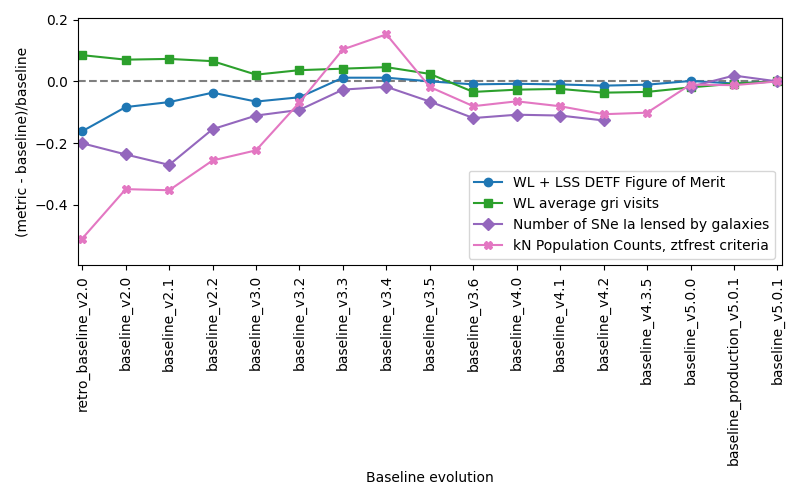

In [79]:
plot_individual_sims(maf_output_rel, metric_names, baseline_sims, probes=probes_to_plot, ylabel=y_label, 
                     xlabel = 'Baseline evolution', expand_ylim_by=[1.1, 1.1], figsize=(8,5), 
                     tick_labels=tick_labels,
                     legend_outside=False)

Now we can drop the older baseline sims and just keep the latest version

In [80]:
baseline_sims = [b for b in baseline_sims if b != baseline]

In [81]:
inds = maf_output.index[~np.isin(maf_output.index, baseline_sims)]
maf_output = maf_output.loc[inds]
maf_output_rel = maf_output_rel.loc[inds]

# Weather simulations

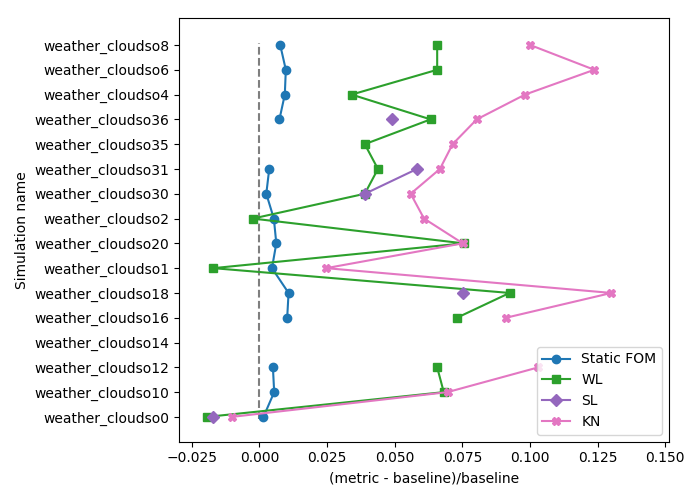

In [82]:
plt.close('all')
sims_to_plot = [s for s in maf_output_rel.index if 'weather' in s and 'poor' not in s]
tick_labels = [sim.split('v5.')[0] for sim in sims_to_plot]
plot_individual_sims(maf_output_rel, metric_names, sims_to_plot, tick_labels=tick_labels, probes=probes_to_plot, 
                     ylabel=y_label, 
                     xlabel = 'Simulation name', expand_ylim_by=[1.1, 1.1], figsize=(7,5), 
                     legend_outside=False, plot_vertical=True)
plt.gca().get_legend().set_visible(False)
plt.tight_layout()
plt.ylim([-1, plt.ylim()[1]+1])
plt.legend(plt.gca().lines[1:], short_labels, loc='lower right')

## Get errors from weather simulations

In [83]:
sims_to_plot = [s for s in maf_output_rel.index if 'weather' in s and 'poor' not in s]
error_dict = {}
for p in probes_to_plot:
    metric = get_full_metric_name(p, metric_names)
    # Propagation of errors
    error_dict[p] = maf_output_full.loc[sims_to_plot, metric].std()/maf_output_full.loc[baseline, metric]

In [84]:
error_dict

{'fom': np.float64(0.00291851104364868),
 'wl': np.float64(0.03438696186550581),
 'sl': np.float64(0.035114738932575176),
 'kn': np.float64(0.03599113354627908)}

# DDF dithering simulations

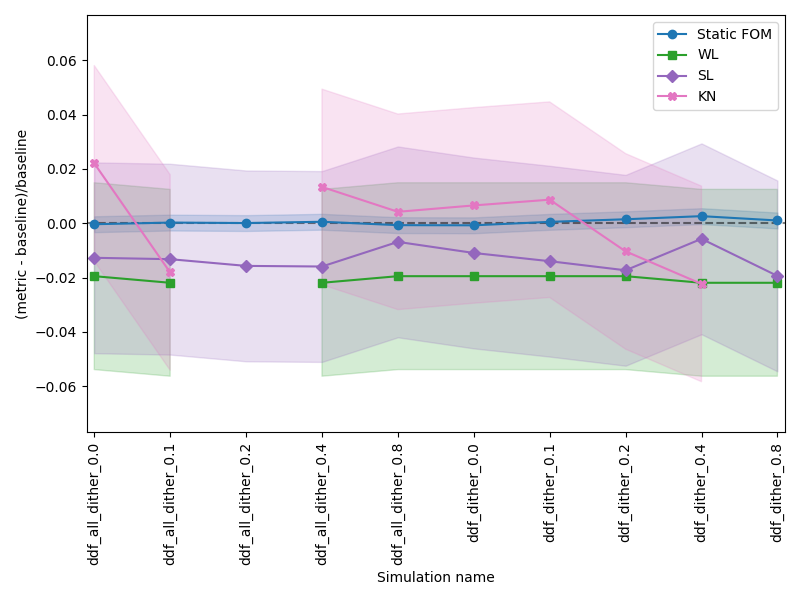

In [85]:
plt.close('all')
sims_to_plot = [s for s in maf_output_rel.index if 'dither' in s]
tick_labels = [sim.split('_v5')[0] for sim in sims_to_plot]
plot_individual_sims(maf_output_rel, metric_names, sims_to_plot, 
                     tick_labels=tick_labels, 
                     probes=probes_to_plot, 
                     error_dict=error_dict,
                     labels_dict=labels_dict,
                     ylabel=y_label, 
                     xlabel = 'Simulation name', 
                     expand_ylim_by=[1.2, 1.2], 
                     figsize=(8,6), 
                     legend_outside=False, 
                     plot_vertical=False)
# plt.gca().get_legend().set_visible(False)
plt.tight_layout()
# plt.ylim([-0.5, plt.ylim()[1]+0.5])
# plt.legend(plt.gca().lines[1:], short_labels, loc='upper right')

# Everything else

(-1.0, 15.1)

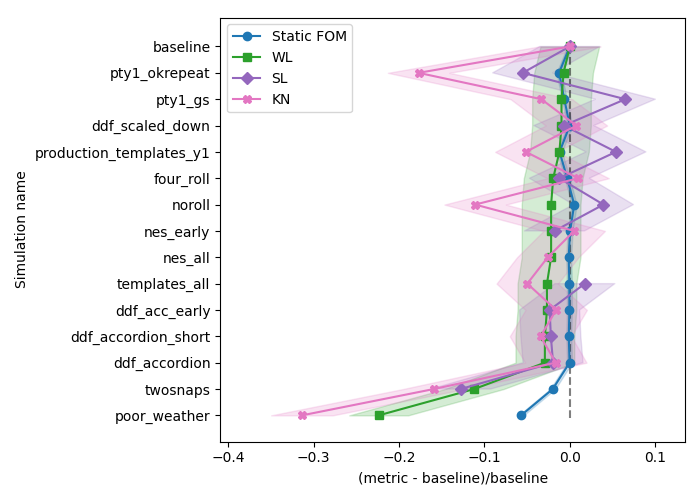

In [59]:
plt.close('all')
keys_to_avoid = ['weather_clo', 'dither', 'retrospec', 'moredt_', 'new_', 'tma_'] 
sims_to_plot = [s for s in maf_output_rel.index if all(key not in s for key in keys_to_avoid)]

# Sort using WL
sims_to_plot = maf_output_rel.loc[sims_to_plot, get_full_metric_name('wl', metric_names)].sort_values().index

tick_labels = [sim.split('_v5')[0] for sim in sims_to_plot]
plot_individual_sims(maf_output_rel, metric_names, sims_to_plot, 
                     error_dict=error_dict, 
                     labels_dict=labels_dict,
                     tick_labels=tick_labels, probes=probes_to_plot, 
                     ylabel=y_label, 
                     xlabel = 'Simulation name', expand_ylim_by=[1.1, 1.1], figsize=(7,5), 
                     legend_outside=False, plot_vertical=True)
plt.tight_layout()
plt.ylim([-1, plt.ylim()[1]+1])
